<a href="https://colab.research.google.com/github/Syamalatha11/Ai-based-hiring-prediction-system-/blob/main/AI_HIRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('/content/AI-Based Hiring Prediction System (1).csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   Resume_ID              Name                                        Skills  \
0          1        Ashley Ali                      TensorFlow, NLP, Pytorch   
1          2      Wesley Roman  Deep Learning, Machine Learning, Python, SQL   
2          3     Corey Sanchez         Ethical Hacking, Cybersecurity, Linux   
3          4  Elizabeth Carney                   Python, Pytorch, TensorFlow   
4          5        Julie Hill                              SQL, React, Java   

   Experience (Years) Education                Certifications  \
0                  10      B.Sc                           NaN   
1                  10       MBA                     Google ML   
2                   1       MBA  Deep Learning Specialization   
3                   7    B.Tech                 AWS Certified   
4                   4       PhD                           NaN   

                Job Role Recruiter Decision  Salary Expectation ($)  \
0          AI Researcher               Hire              

In [ ]:
print(df.columns)

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')


In [ ]:
print(df['Recruiter Decision'].value_counts())

Recruiter Decision
Hire      812
Reject    188
Name: count, dtype: int64


In [ ]:
df.fillna('Unknown', inplace=True)

In [ ]:
df['Recruiter Decision'] = df['Recruiter Decision'].map({
    'Hire':1,
    'Reject':0
})

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    if col != 'Recruiter Decision':
        df[col] = le.fit_transform(df[col].astype(str))

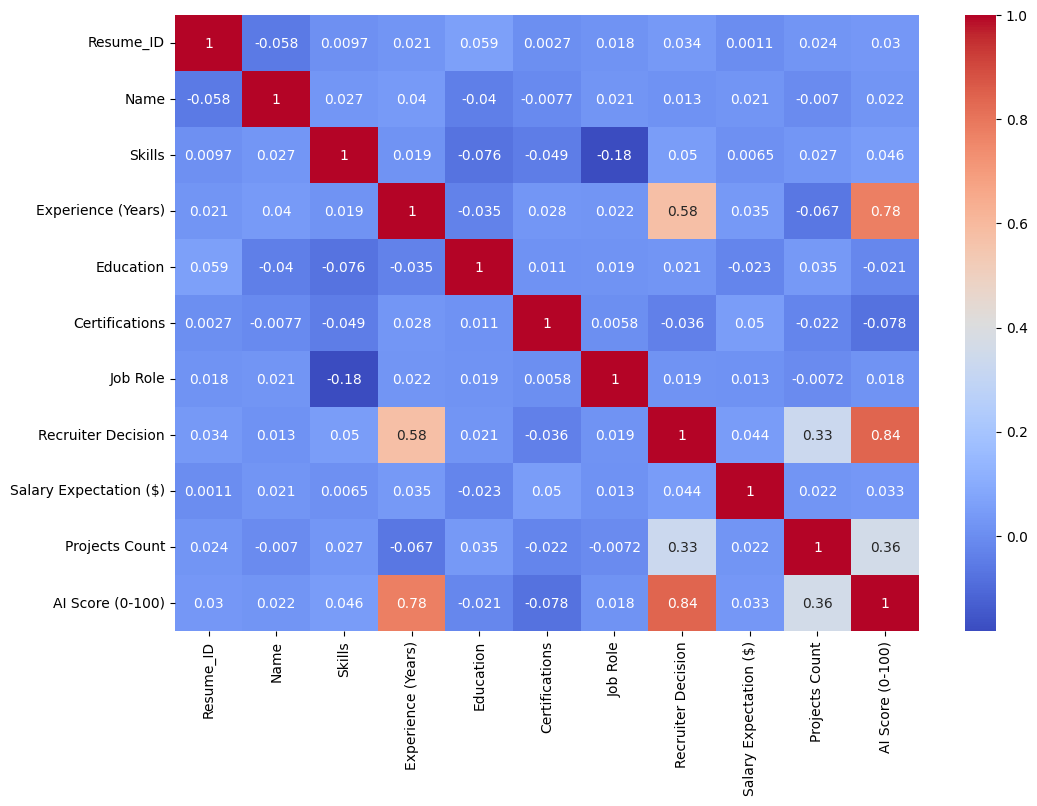

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
X = df.drop('Recruiter Decision', axis=1)
y = df['Recruiter Decision']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.985
Precision: 0.9937888198757764
Recall: 0.9876543209876543
F1 Score: 0.9907120743034056
[[ 37   1]
 [  2 160]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        38
           1       0.99      0.99      0.99       162

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200



In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [ ]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        dt_acc,
        rf_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.985
1        Decision Tree     1.000
2        Random Forest     1.000


In [ ]:
params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00       162

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 38   0]
 [  0 162]]


AI Score (0-100)          0.691645
Experience (Years)        0.210877
Projects Count            0.058811
Resume_ID                 0.009412
Salary Expectation ($)    0.009143
Name                      0.007738
Skills                    0.005607
Education                 0.002818
Certifications            0.002456
Job Role                  0.001493
dtype: float64


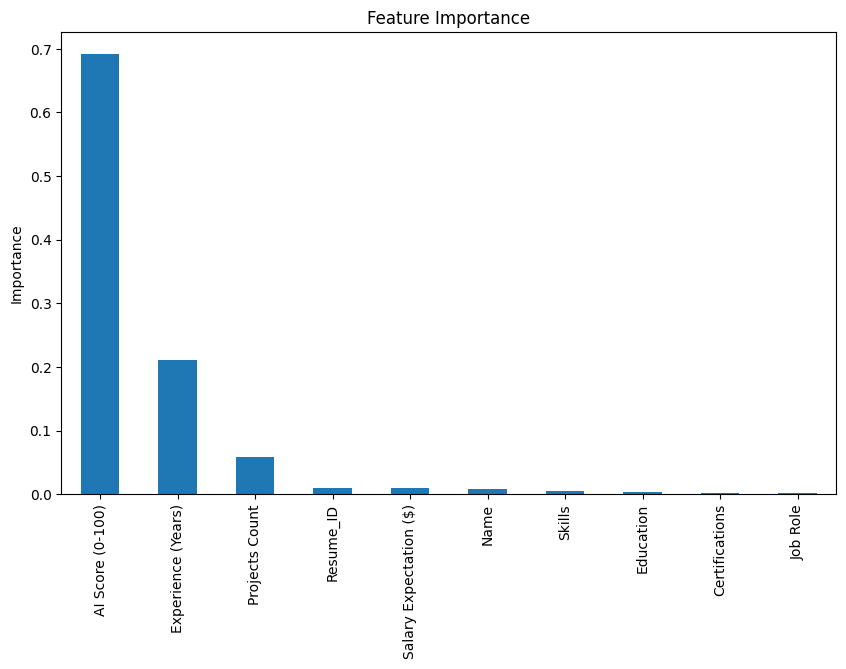

In [ ]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()